# Анализ качества моделей суммаризации текста

## Три типа сравнений для каждой метрики:
1. **ОТ-АР** — Оригинальный текст vs Авторский реферат
2. **ОТ-СР** — Оригинальный текст vs Сгенерированные рефераты
3. **АР-СР** — Авторский реферат vs Сгенерированные рефераты

## Модели суммаризации (СР):
- **а** — Лингвистический суммаризатор (Lingvo)
- **б** — csebuetnlp/mT5_multilingual_XLSum
- **в** — IlyaGusev/mbart_ru_sum_gazeta
- **г** — IlyaGusev/rut5_base_sum_gazeta
- **д** — utrobinmv/t5_summary_en_ru_zh_base_2048
- **е** — TextRank
- **ж** — LexRank

## 1. Импорт библиотек и загрузка данных

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sacrebleu.metrics import CHRF
# import pymorphy3
import re
import warnings
import json

warnings.filterwarnings('ignore')

# Настройка стиля
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Метки моделей (7 штук)
SHORT_LABELS = ['а', 'б', 'в', 'г', 'д', 'е', 'ж']
FULL_LABELS = ['Лингвистический суммаризатор', 'TextRank', 'LexRank', 
               'csebuetnlp/mT5_multilingual_XLSum', 'IlyaGusev/mbart_ru_sum_gazeta', 
               'IlyaGusev/rut5_base_sum_gazeta', 'utrobinmv/t5_summary_en_ru_zh_base_2048']

# Цвета для моделей
MODEL_COLORS = ['#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#1abc9c', '#e74c3c', '#95a5a6']

print('Библиотеки загружены')

Библиотеки загружены


In [4]:
# Загрузка данных
df = pd.read_csv('data-tables/data-full.csv')


In [3]:
import sqlite3
import pandas as pd

# Укажите путь к вашему .db файлу
db_path = 'cyberleninka.db'
# Имя таблицы (замените на актуальное)
table_name = 'articles'

# Подключаемся к базе
conn = sqlite3.connect(db_path)

# Формируем запрос: выбираем случайные 500 записей с нужными колонками
query = f"""
SELECT full_text, abstract
FROM {table_name}
WHERE id > 1500
ORDER BY RANDOM()
LIMIT 500;
"""

# Выполняем запрос и получаем DataFrame
df = pd.read_sql_query(query, conn)
df = df.rename(columns={'full_text':'source_text', 'abstract':'target_summary'})

# Закрываем соединение
conn.close()

# Теперь df содержит 500 случайных строк, с которыми можно работать дальше
print(df.head())

                                         source_text  \
0  ﻿Медведев Михаил Юрьевич - Южный федеральный у...   
1  ﻿relevant. The paper defines the purpose and s...   
2  ﻿МЕТОДЫ И СИСТЕМЫ ЗАЩИТЫ ИНФОРМАЦИИ, ИНФОРМАЦИ...   
3  ﻿Dorofeev Nikolay Viktorovich, doctor of techn...   
4  ﻿22. Эндрюс Г.Р. Основы многопоточного, паралл...   

                                      target_summary  
0  Предпосылкой использованиянейронных сетейв кач...  
1  В работе освещается важность систем мониторинг...  
2  Для динамически изменяющихся объектов управлен...  
3  В статье рассматриваются оценка степениосведом...  
4  Анализируются на основе зарубежных исследовани...  


In [5]:
# Определяем колонки
OT_COL = 'source_text'       # Оригинальный текст (ОТ)
AR_COL = 'target_summary'    # Авторский реферат (АР)
SR_COLS = ['summary_lingvo', 'summary_TextRank', 'summary_LexRank', 
           'summary_mt5', 'summary_mbart', 'summary_rut5', 'summary_t5']  # Сгенерированные рефераты (СР)

# Очистка данных
required_cols = [OT_COL, AR_COL] + SR_COLS if len(df.columns) > 2 else [OT_COL, AR_COL]
df_clean = df[required_cols].dropna()

print(f'Загружено документов: {len(df_clean)}')
print(f'\nОТ (Оригинальный текст): {OT_COL}')
print(f'АР (Авторский реферат): {AR_COL}')
if len(df_clean.columns) > 2:
    print(f'СР (Сгенерированные рефераты): {SR_COLS}')

df_clean.head(2)

Загружено документов: 479

ОТ (Оригинальный текст): source_text
АР (Авторский реферат): target_summary
СР (Сгенерированные рефераты): ['summary_lingvo', 'summary_TextRank', 'summary_LexRank', 'summary_mt5', 'summary_mbart', 'summary_rut5', 'summary_t5']


,source_text,target_summary,summary_lingvo,summary_TextRank,summary_LexRank,summary_mt5,summary_mbart,summary_rut5,summary_t5
0,Оценка вклада глутатионовой системы и продукто...,"Результаты последних исследований, в том числе...",Оценка вклада глутатионовой системы и продукто...,Оценка вклада глутатионовой системы и продукто...,У женщин русского этноса при\nналичии инсомнии...,"Российское научное исследование показало, что ...",Вклад глутатионовой системы и продуктов окисле...,Нарушения свободнорадикального гомеостаза у же...,"По данным Минздрава России, средняя продолжите..."
1,Пластика передней таранно-малоберцовой связки ...,Травма голеностопного сустава признана одной и...,Пластика передней таранно-малоберцовой связки ...,Пластика передней таранно-малоберцовой связки ...,"И практикующие врачи, и исследователи продолжа...",В очередной подборке интересных научных новост...,Наибольшее количество острого растяжения связо...,В США более половины случаев острого растяжени...,В общей популяции жителей США по данным ряда и...


## 2. Анализ длины текстов

In [6]:
# Вычисляем длины текстов (в словах)
def count_words(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())

# Длины
len_ot = df_clean[OT_COL].apply(count_words).values  # Оригинальный текст
len_ar = df_clean[AR_COL].apply(count_words).values  # Авторский реферат
if len(df_clean.columns) > 2:
    len_sr = {col: df_clean[col].apply(count_words).values for col in SR_COLS}  # Сгенерированные

print('Средняя длина (слова):')
print(f'  ОТ (Оригинал): {len_ot.mean():.0f}')
print(f'  АР (Авторский): {len_ar.mean():.0f}')

if len(df_clean.columns) > 2:
    for col, label in zip(SR_COLS, FULL_LABELS):
        print(f'  {label}: {len_sr[col].mean():.0f}')

Средняя длина (слова):
  ОТ (Оригинал): 2620
  АР (Авторский): 98
  Лингвистический суммаризатор: 285
  TextRank: 862
  LexRank: 75
  csebuetnlp/mT5_multilingual_XLSum: 99
  IlyaGusev/mbart_ru_sum_gazeta: 193
  IlyaGusev/rut5_base_sum_gazeta: 188
  utrobinmv/t5_summary_en_ru_zh_base_2048: 131


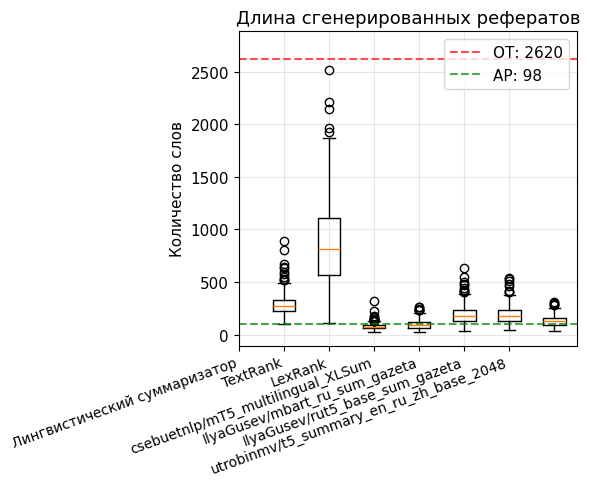

In [10]:
# График длины: 3 подграфика
# fig, axes = plt.subplots(1, 3, figsize=(12, 5), tight_layout=True, width_ratios=[1, 3, 3])
fig, axes = plt.subplots(1, 1, figsize=(6, 5))

# ОТ-АР: сравнение длины ОТ и АР
# bp1 = axes[0].boxplot([len_ot, len_ar], labels=['ОТ', 'АР'], widths=0.4)
# axes[0].set_title('Длина: ОТ vs АР')
# axes[0].set_ylabel('Количество слов')
# axes[0].grid(True, alpha=0.3)

# ОТ-СР: длина СР (для контекста)
data_sr = [len_sr[col] for col in SR_COLS]
bp2 = axes.boxplot(data_sr, labels=SHORT_LABELS)
axes.axhline(y=len_ot.mean(), color='red', linestyle='--', alpha=0.7, label=f'ОТ: {len_ot.mean():.0f}')
axes.axhline(y=len_ar.mean(), color='green', linestyle='--', alpha=0.7, label=f'АР: {len_ar.mean():.0f}')
axes.set_title('Длина сгенерированных рефератов')
axes.set_ylabel('Количество слов')
axes.set_ylim(ymax=2620*1.1)
axes.legend(loc='upper right')
axes.grid(True, alpha=0.3)

# АР-СР: длина СР относительно АР
# bp3 = axes[2].boxplot(data_sr, labels=SHORT_LABELS)
# axes[2].axhline(y=len_ar.mean(), color='green', linestyle='--', alpha=0.7, label=f'АР: {len_ar.mean():.0f}')
# axes[2].set_title('Длина СР (сравнение с АР)')
# axes[2].set_ylabel('Количество слов')
# axes[2].legend(loc='upper right')
# axes[2].grid(True, alpha=0.3)

plt.xticks(ticks=range(len(df_clean.columns[2:])), labels=FULL_LABELS, ha='right', rotation=20, fontsize=10,)
plt.tight_layout()
plt.savefig('length_3comparisons.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Сохранение длин и степеней сжатия в JSON
lengths_data = {
    'ОТ': len_ot.tolist(),
    'АР': len_ar.tolist(),
    'СР': {col: len_sr[col].tolist() for col in SR_COLS},
    'compression_ratio': {
        'АР': (len_ar / len_ot).tolist(),
        **{col: (len_sr[col] / len_ot).tolist() for col in SR_COLS}
    }
}

with open('lengths.json', 'w', encoding='utf-8') as json_file:
    json.dump(lengths_data, json_file, ensure_ascii=False, indent=4)

print('Длины и степени сжатия сохранены в lengths.json')
print(f'  ОТ: средняя длина = {len_ot.mean():.0f} слов')
print(f'  АР: средняя длина = {len_ar.mean():.0f} слов, средняя степень сжатия = {(len_ar / len_ot).mean():.3f}')
for col, label in zip(SR_COLS, FULL_LABELS):
    ratio = (len_sr[col] / len_ot).mean()
    print(f'  {label}: средняя длина = {len_sr[col].mean():.0f} слов, степень сжатия = {ratio:.3f}')

## 3. ROUGE метрики

In [5]:
from rouge import Rouge

rouge = Rouge()

# Структура для хранения результатов: precision, recall, fmeasure для каждой метрики
rouge_results = {
    'ОТ-АР': {
        'rouge1': {'p': [], 'r': [], 'f': []},
        'rouge2': {'p': [], 'r': [], 'f': []},
        'rougeL': {'p': [], 'r': [], 'f': []}
    },
    'ОТ-СР': {col: {
        'rouge1': {'p': [], 'r': [], 'f': []},
        'rouge2': {'p': [], 'r': [], 'f': []},
        'rougeL': {'p': [], 'r': [], 'f': []}
    } for col in SR_COLS},
    'АР-СР': {col: {
        'rouge1': {'p': [], 'r': [], 'f': []},
        'rouge2': {'p': [], 'r': [], 'f': []},
        'rougeL': {'p': [], 'r': [], 'f': []}
    } for col in SR_COLS}
}

# Маппинг ключей: rouge library -> наши ключи
ROUGE_KEY_MAP = {'rouge-1': 'rouge1', 'rouge-2': 'rouge2', 'rouge-l': 'rougeL'}

def extract_rouge_scores(scores_list):
    """Извлекает p, r, f из результата rouge.get_scores()"""
    s = scores_list[0]  # get_scores возвращает список
    result = {}
    for rouge_key, our_key in ROUGE_KEY_MAP.items():
        result[our_key] = {'p': s[rouge_key]['p'], 'r': s[rouge_key]['r'], 'f': s[rouge_key]['f']}
    return result

print('Вычисление ROUGE метрик...')
for idx in tqdm(range(len(df_clean))):
    ot = str(df_clean[OT_COL].iloc[idx])
    ar = str(df_clean[AR_COL].iloc[idx])

    # 1. ОТ-АР
    scores = extract_rouge_scores(rouge.get_scores(ar, ot))
    for metric in ['rouge1', 'rouge2', 'rougeL']:
        for measure in ['p', 'r', 'f']:
            rouge_results['ОТ-АР'][metric][measure].append(scores[metric][measure])

    # 2. ОТ-СР и 3. АР-СР
    for col in SR_COLS:
        sr = str(df_clean[col].iloc[idx])

        # ОТ vs СР
        scores_ot_sr = extract_rouge_scores(rouge.get_scores(sr, ot))
        for metric in ['rouge1', 'rouge2', 'rougeL']:
            for measure in ['p', 'r', 'f']:
                rouge_results['ОТ-СР'][col][metric][measure].append(scores_ot_sr[metric][measure])

        # АР vs СР
        scores_ar_sr = extract_rouge_scores(rouge.get_scores(sr, ar))
        for metric in ['rouge1', 'rouge2', 'rougeL']:
            for measure in ['p', 'r', 'f']:
                rouge_results['АР-СР'][col][metric][measure].append(scores_ar_sr[metric][measure])

print('ROUGE вычислен!')

Вычисление ROUGE метрик...


100%|██████████| 479/479 [00:08<00:00, 54.91it/s]

ROUGE вычислен!


In [8]:
with open('rouge.json', 'w', encoding='utf-8') as json_file:
    json.dump(rouge_results, json_file, ensure_ascii=False, indent=4)

In [6]:
# Сводная таблица ROUGE
print('=== Средние значения ROUGE (F1) ===')
print('\n--- ОТ-АР ---')
for metric in ['rouge1', 'rouge2', 'rougeL']:
    print(f'{metric}: {np.mean(rouge_results["ОТ-АР"][metric]["f"]):.4f}')

print('\n--- ОТ-СР ---')
for col, label in zip(SR_COLS, FULL_LABELS):
    r1 = np.mean(rouge_results['ОТ-СР'][col]['rouge1']['f'])
    print(f'{label}: R1={r1:.4f}')

print('\n--- АР-СР ---')
for col, label in zip(SR_COLS, FULL_LABELS):
    r1 = np.mean(rouge_results['АР-СР'][col]['rouge1']['f'])
    print(f'{label}: R1={r1:.4f}')

=== Средние значения ROUGE (F1) ===

--- ОТ-АР ---
rouge1: 0.0521
rouge2: 0.0323
rougeL: 0.0487

--- ОТ-СР ---
Лингвистический суммаризатор: R1=0.2260
TextRank: R1=0.3798
LexRank: R1=0.0329
csebuetnlp/mT5_multilingual_XLSum: R1=0.0268
IlyaGusev/mbart_ru_sum_gazeta: R1=0.0775
IlyaGusev/rut5_base_sum_gazeta: R1=0.0688
utrobinmv/t5_summary_en_ru_zh_base_2048: R1=0.0766

--- АР-СР ---
Лингвистический суммаризатор: R1=0.1247
TextRank: R1=0.1025
LexRank: R1=0.1151
csebuetnlp/mT5_multilingual_XLSum: R1=0.0779
IlyaGusev/mbart_ru_sum_gazeta: R1=0.1439
IlyaGusev/rut5_base_sum_gazeta: R1=0.1326
utrobinmv/t5_summary_en_ru_zh_base_2048: R1=0.1100


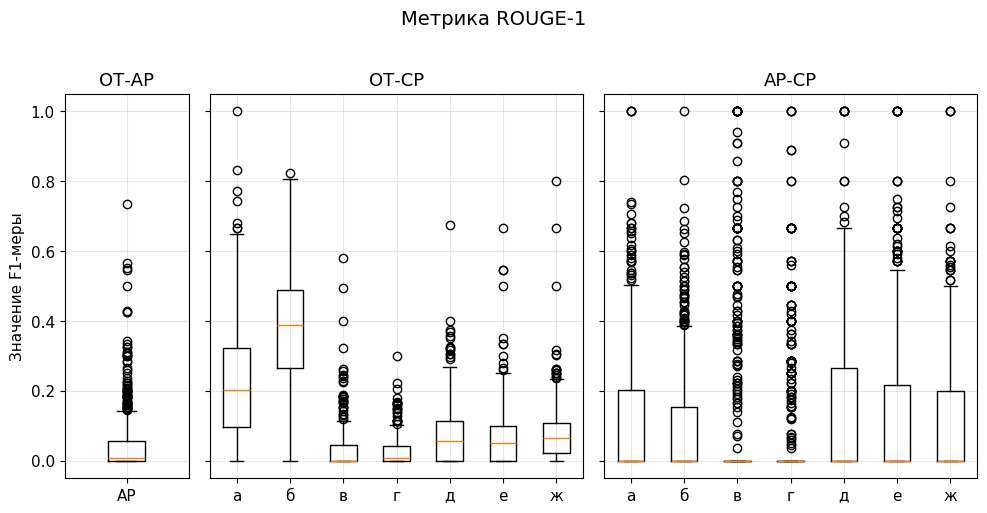

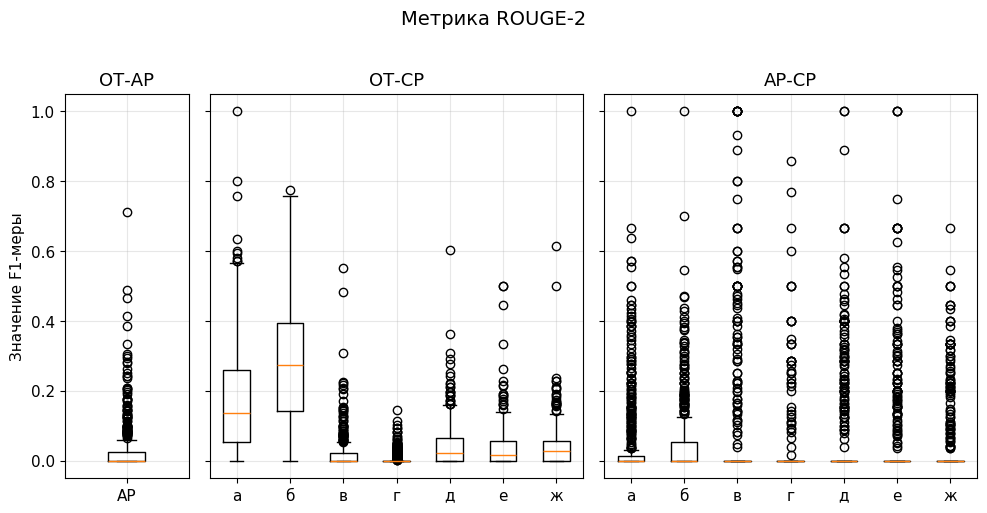

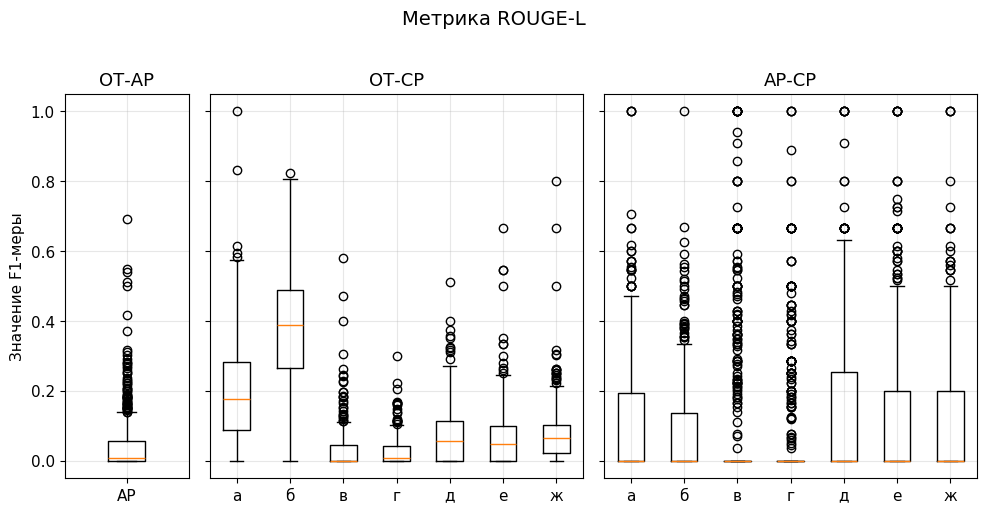

In [7]:
# Графики ROUGE: по одному для каждой метрики (rouge1, rouge2, rougeL)
for metric, metric_title in [('rouge1', 'ROUGE-1'), ('rouge2', 'ROUGE-2'), ('rougeL', 'ROUGE-L')]:
    fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True, tight_layout=True, width_ratios=[1, 3, 3])

    # ОТ-АР (1 boxplot)
    axes[0].boxplot([rouge_results['ОТ-АР'][metric]['f']], labels=['АР'], widths=0.3)
    axes[0].set_title('ОТ-АР')
    axes[0].set_ylabel('Значение F1-меры')
    axes[0].grid(True, alpha=0.3)

    # ОТ-СР (5 boxplots)
    data_ot_sr = [rouge_results['ОТ-СР'][col][metric]['f'] for col in SR_COLS]
    axes[1].boxplot(data_ot_sr, labels=SHORT_LABELS)
    axes[1].set_title('ОТ-СР')
    axes[1].grid(True, alpha=0.3)

    # АР-СР (5 boxplots)
    data_ar_sr = [rouge_results['АР-СР'][col][metric]['f'] for col in SR_COLS]
    axes[2].boxplot(data_ar_sr, labels=SHORT_LABELS)
    axes[2].set_title('АР-СР')
    axes[2].grid(True, alpha=0.3)

    fig.suptitle(f'Метрика {metric_title}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{metric}_3comparisons.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. BLEU метрика

In [9]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smoothie = SmoothingFunction().method4

# Структура для результатов
bleu_results = {
    'ОТ-АР': [],
    'ОТ-СР': {col: [] for col in SR_COLS},
    'АР-СР': {col: [] for col in SR_COLS}
}

print('Вычисление BLEU...')
for idx in tqdm(range(len(df_clean))):
    ot_tokens = str(df_clean[OT_COL].iloc[idx]).split()
    ar_tokens = str(df_clean[AR_COL].iloc[idx]).split()
    
    # ОТ-АР
    try:
        score = sentence_bleu([ot_tokens], ar_tokens, smoothing_function=smoothie)
    except:
        score = 0.0
    bleu_results['ОТ-АР'].append(score)
    
    # ОТ-СР и АР-СР
    for col in SR_COLS:
        sr_tokens = str(df_clean[col].iloc[idx]).split()
        
        # ОТ vs СР
        try:
            score_ot = sentence_bleu([ot_tokens], sr_tokens, smoothing_function=smoothie)
        except:
            score_ot = 0.0
        bleu_results['ОТ-СР'][col].append(score_ot)
        
        # АР vs СР
        try:
            score_ar = sentence_bleu([ar_tokens], sr_tokens, smoothing_function=smoothie)
        except:
            score_ar = 0.0
        bleu_results['АР-СР'][col].append(score_ar)

print('BLEU вычислен!')

Вычисление BLEU...


100%|██████████| 479/479 [00:17<00:00, 26.68it/s]

BLEU вычислен!


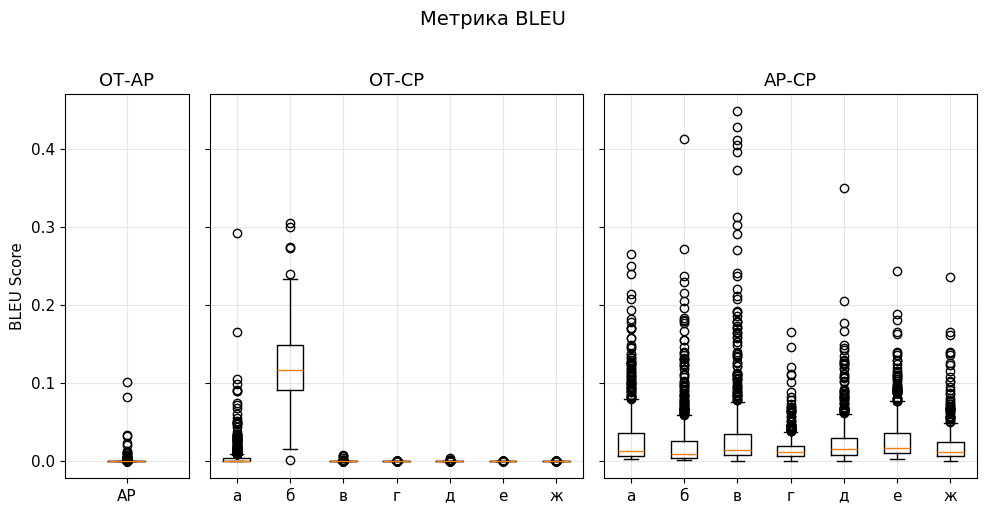

In [10]:
# График BLEU: 3 подграфика
fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True, tight_layout=True, width_ratios=[1, 3, 3])

# ОТ-АР
axes[0].boxplot([bleu_results['ОТ-АР']], labels=['АР'], widths=0.3)
axes[0].set_title('ОТ-АР')
axes[0].set_ylabel('BLEU Score')
axes[0].grid(True, alpha=0.3)

# ОТ-СР
data_ot_sr = [bleu_results['ОТ-СР'][col] for col in SR_COLS]
axes[1].boxplot(data_ot_sr, labels=SHORT_LABELS)
axes[1].set_title('ОТ-СР')
axes[1].grid(True, alpha=0.3)

# АР-СР
data_ar_sr = [bleu_results['АР-СР'][col] for col in SR_COLS]
axes[2].boxplot(data_ar_sr, labels=SHORT_LABELS)
axes[2].set_title('АР-СР')
axes[2].grid(True, alpha=0.3)

fig.suptitle('Метрика BLEU', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('bleu_3comparisons.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
with open('bleu.json', 'w', encoding='utf-8') as json_file:
    json.dump(bleu_results, json_file, ensure_ascii=False, indent=4)

## 4.5. chrF++ метрика

chrF++ - character-level метрика, устойчивая к морфологическому разнообразию русского языка.

In [12]:
# Инициализация chrF++
chrf_scorer = CHRF(word_order=2)  # chrF++ использует word_order=2

# Структура для результатов
chrf_results = {
    'ОТ-АР': [],
    'ОТ-СР': {col: [] for col in SR_COLS},
    'АР-СР': {col: [] for col in SR_COLS}
}

print('Вычисление chrF++...')
for idx in tqdm(range(len(df_clean))):
    ot_text = str(df_clean[OT_COL].iloc[idx])
    ar_text = str(df_clean[AR_COL].iloc[idx])
    
    # ОТ-АР
    score = chrf_scorer.sentence_score(ar_text, [ot_text]).score / 100  # Нормализуем к [0, 1]
    chrf_results['ОТ-АР'].append(score)
    
    # ОТ-СР и АР-СР
    for col in SR_COLS:
        sr_text = str(df_clean[col].iloc[idx])
        
        # ОТ vs СР
        score_ot = chrf_scorer.sentence_score(sr_text, [ot_text]).score / 100
        chrf_results['ОТ-СР'][col].append(score_ot)
        
        # АР vs СР
        score_ar = chrf_scorer.sentence_score(sr_text, [ar_text]).score / 100
        chrf_results['АР-СР'][col].append(score_ar)

print('chrF++ вычислен!')
print(f"\nСреднее chrF++ для ОТ-АР: {np.mean(chrf_results['ОТ-АР']):.4f}")

Вычисление chrF++...


100%|██████████| 479/479 [02:16<00:00,  3.52it/s]

chrF++ вычислен!

Среднее chrF++ для ОТ-АР: 0.0495


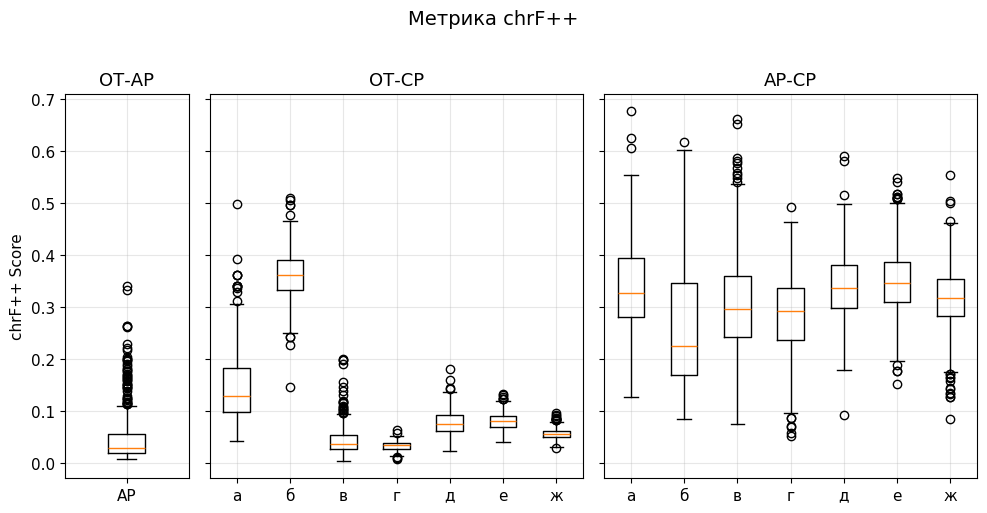

In [13]:
# График chrF++: 3 подграфика
fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True, tight_layout=True, width_ratios=[1, 3, 3])

# ОТ-АР
axes[0].boxplot([chrf_results['ОТ-АР']], labels=['АР'], widths=0.3)
axes[0].set_title('ОТ-АР')
axes[0].set_ylabel('chrF++ Score')
axes[0].grid(True, alpha=0.3)

# ОТ-СР
data_ot_sr = [chrf_results['ОТ-СР'][col] for col in SR_COLS]
axes[1].boxplot(data_ot_sr, labels=SHORT_LABELS)
axes[1].set_title('ОТ-СР')
axes[1].grid(True, alpha=0.3)

# АР-СР
data_ar_sr = [chrf_results['АР-СР'][col] for col in SR_COLS]
axes[2].boxplot(data_ar_sr, labels=SHORT_LABELS)
axes[2].set_title('АР-СР')
axes[2].grid(True, alpha=0.3)

fig.suptitle('Метрика chrF++', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('chrf_3comparisons.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
with open('chrf.json', 'w', encoding='utf-8') as json_file:
    json.dump(chrf_results, json_file, ensure_ascii=False, indent=4)

## 4.6. METEOR (адаптация для русского языка)

METEOR (Metric for Evaluation of Translation with Explicit ORdering) с адаптацией для русского:
- Использует **лемматизацию через pymorphy2** вместо стемминга
- Учитывает **порядок слов** через штраф за фрагментацию
- Более устойчив к морфологическому разнообразию русского языка

Формула: `METEOR = F_mean × (1 - Penalty)`

In [15]:
# Инициализация морфологического анализатора
morph = pymorphy3.MorphAnalyzer()

def tokenize_ru(text):
    """Токенизация русского текста"""
    # Приводим к нижнему регистру и извлекаем слова
    text = str(text).lower()
    tokens = re.findall(r'[а-яёa-z0-9]+', text)
    return tokens

def lemmatize_ru(tokens):
    """Лемматизация списка токенов"""
    return [morph.parse(token)[0].normal_form for token in tokens]

def meteor_score_ru(reference, hypothesis, alpha=0.9, beta=3.0, gamma=0.5):
    """
    Вычисляет METEOR score для русского языка.
    
    Parameters:
    -----------
    reference : str - эталонный текст
    hypothesis : str - оцениваемый текст
    alpha : float - вес precision vs recall (по умолчанию 0.9 = больше вес recall)
    beta : float - параметр штрафа за фрагментацию
    gamma : float - максимальный штраф за фрагментацию
    
    Returns:
    --------
    float : METEOR score в диапазоне [0, 1]
    """
    # Токенизация
    ref_tokens = tokenize_ru(reference)
    hyp_tokens = tokenize_ru(hypothesis)
    
    if len(ref_tokens) == 0 or len(hyp_tokens) == 0:
        return 0.0
    
    # Лемматизация
    ref_lemmas = lemmatize_ru(ref_tokens)
    hyp_lemmas = lemmatize_ru(hyp_tokens)
    
    # Stage 1: Exact match на леммах
    ref_matched = [False] * len(ref_lemmas)
    hyp_matched = [False] * len(hyp_lemmas)
    
    matches = 0
    for i, h_lemma in enumerate(hyp_lemmas):
        for j, r_lemma in enumerate(ref_lemmas):
            if not ref_matched[j] and h_lemma == r_lemma:
                ref_matched[j] = True
                hyp_matched[i] = True
                matches += 1
                break
    
    if matches == 0:
        return 0.0
    
    # Precision и Recall
    precision = matches / len(hyp_lemmas)
    recall = matches / len(ref_lemmas)
    
    # F-mean (гармоническое среднее с весом alpha)
    if precision + recall == 0:
        return 0.0
    f_mean = (precision * recall) / (alpha * precision + (1 - alpha) * recall)
    
    # Stage 2: Вычисление chunks (непрерывных последовательностей совпадений)
    chunks = 0
    in_chunk = False
    
    # Находим позиции совпавших слов в reference для каждого совпавшего слова в hypothesis
    hyp_to_ref_pos = []
    ref_used = [False] * len(ref_lemmas)
    
    for i, h_lemma in enumerate(hyp_lemmas):
        if hyp_matched[i]:
            for j, r_lemma in enumerate(ref_lemmas):
                if not ref_used[j] and h_lemma == r_lemma:
                    hyp_to_ref_pos.append(j)
                    ref_used[j] = True
                    break
    
    # Считаем chunks
    if len(hyp_to_ref_pos) > 0:
        chunks = 1
        for i in range(1, len(hyp_to_ref_pos)):
            if hyp_to_ref_pos[i] != hyp_to_ref_pos[i-1] + 1:
                chunks += 1
    
    # Penalty за фрагментацию
    if matches > 0:
        frag = chunks / matches
        penalty = gamma * (frag ** beta)
    else:
        penalty = 0
    
    # Финальный METEOR score
    meteor = f_mean * (1 - penalty)
    
    return max(0.0, meteor)

# Тест функции
test_ref = "Исследование показало высокую эффективность метода лечения"
test_hyp = "Метод лечения показал высокую эффективность в исследовании"
print(f"Тест METEOR: {meteor_score_ru(test_ref, test_hyp):.4f}")
print(f"(ожидается высокий score, т.к. тексты семантически близки)")

Тест METEOR: 0.9221
(ожидается высокий score, т.к. тексты семантически близки)


In [16]:
# Структура для результатов METEOR
meteor_results = {
    'ОТ-АР': [],
    'ОТ-СР': {col: [] for col in SR_COLS},
    'АР-СР': {col: [] for col in SR_COLS}
}

print('Вычисление METEOR (Russian)...')
print('(это может занять несколько минут из-за лемматизации)')

for idx in tqdm(range(len(df_clean))):
    ot_text = str(df_clean[OT_COL].iloc[idx])
    ar_text = str(df_clean[AR_COL].iloc[idx])
    
    # ОТ-АР (reference=ОТ, hypothesis=АР)
    score = meteor_score_ru(ot_text, ar_text)
    meteor_results['ОТ-АР'].append(score)
    
    # ОТ-СР и АР-СР
    for col in SR_COLS:
        sr_text = str(df_clean[col].iloc[idx])
        
        # ОТ vs СР (reference=ОТ, hypothesis=СР)
        score_ot = meteor_score_ru(ot_text, sr_text)
        meteor_results['ОТ-СР'][col].append(score_ot)
        
        # АР vs СР (reference=АР, hypothesis=СР)
        score_ar = meteor_score_ru(ar_text, sr_text)
        meteor_results['АР-СР'][col].append(score_ar)

print('METEOR вычислен!')
print(f"\nСреднее METEOR для ОТ-АР: {np.mean(meteor_results['ОТ-АР']):.4f}")
print(f"Сравните с BLEU для ОТ-АР: {np.mean(bleu_results['ОТ-АР']):.4f}")
print(f"Сравните с chrF++ для ОТ-АР: {np.mean(chrf_results['ОТ-АР']):.4f}")

Вычисление METEOR (Russian)...
(это может занять несколько минут из-за лемматизации)


100%|██████████| 479/479 [28:33<00:00,  3.58s/it]

METEOR вычислен!

Среднее METEOR для ОТ-АР: 0.0326
Сравните с BLEU для ОТ-АР: 0.0009
Сравните с chrF++ для ОТ-АР: 0.0495


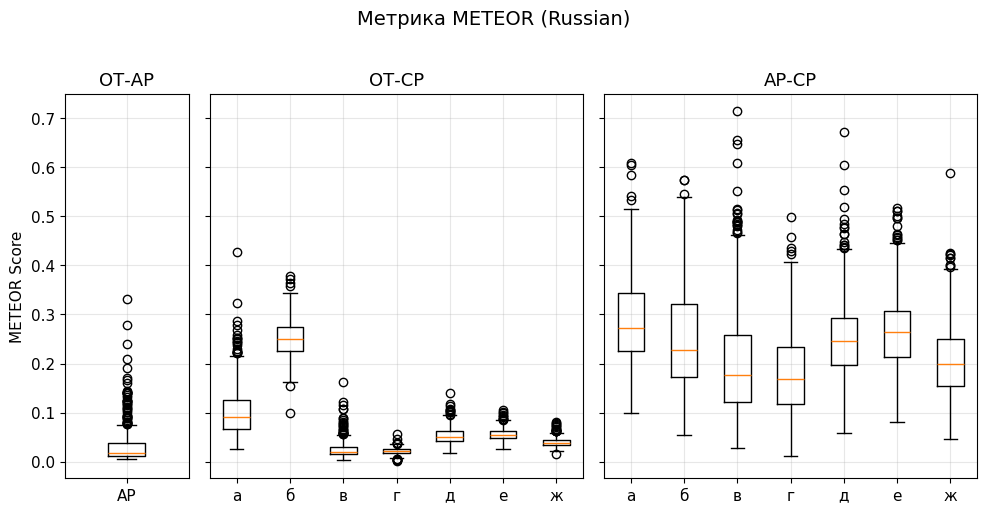

In [17]:
# График METEOR: 3 подграфика
fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True, tight_layout=True, width_ratios=[1, 3, 3])

# ОТ-АР
axes[0].boxplot([meteor_results['ОТ-АР']], labels=['АР'], widths=0.3)
axes[0].set_title('ОТ-АР')
axes[0].set_ylabel('METEOR Score')
axes[0].grid(True, alpha=0.3)

# ОТ-СР
data_ot_sr = [meteor_results['ОТ-СР'][col] for col in SR_COLS]
axes[1].boxplot(data_ot_sr, labels=SHORT_LABELS)
axes[1].set_title('ОТ-СР')
axes[1].grid(True, alpha=0.3)

# АР-СР
data_ar_sr = [meteor_results['АР-СР'][col] for col in SR_COLS]
axes[2].boxplot(data_ar_sr, labels=SHORT_LABELS)
axes[2].set_title('АР-СР')
axes[2].grid(True, alpha=0.3)

fig.suptitle('Метрика METEOR (Russian)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('meteor_ru_3comparisons.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
with open('meteor.json', 'w', encoding='utf-8') as json_file:
    json.dump(meteor_results, json_file, ensure_ascii=False, indent=4)

## 5. BERTScore

In [19]:
import torch
from bert_score import score as bert_score

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {device}')

# Структура для результатов
bertscore_results = {
    'ОТ-АР': {'precision': [], 'recall': [], 'f1': []},
    'ОТ-СР': {col: {'f1': []} for col in SR_COLS},
    'АР-СР': {col: {'f1': []} for col in SR_COLS}
}

# Подготовка данных
ot_texts = df_clean[OT_COL].tolist()
ar_texts = df_clean[AR_COL].tolist()

print('Вычисление BERTScore...')

# 1. ОТ-АР
print('  ОТ-АР...')
P, R, F1 = bert_score(ar_texts, ot_texts, lang='ru', device=device, verbose=False)
bertscore_results['ОТ-АР']['f1'] = F1.tolist()

# 2. ОТ-СР
for col, label in zip(SR_COLS, FULL_LABELS):
    print(f'  ОТ-СР ({label})...')
    sr_texts = df_clean[col].tolist()
    P, R, F1 = bert_score(sr_texts, ot_texts, lang='ru', device=device, verbose=False)
    bertscore_results['ОТ-СР'][col]['f1'] = F1.tolist()

# 3. АР-СР
for col, label in zip(SR_COLS, FULL_LABELS):
    print(f'  АР-СР ({label})...')
    sr_texts = df_clean[col].tolist()
    P, R, F1 = bert_score(sr_texts, ar_texts, lang='ru', device=device, verbose=False)
    bertscore_results['АР-СР'][col]['f1'] = F1.tolist()

print('BERTScore вычислен!')

Устройство: cuda
Вычисление BERTScore...
  ОТ-АР...
  ОТ-СР (Лингвистический суммаризатор)...
  ОТ-СР (TextRank)...
  ОТ-СР (LexRank)...
  ОТ-СР (csebuetnlp/mT5_multilingual_XLSum)...
  ОТ-СР (IlyaGusev/mbart_ru_sum_gazeta)...
  ОТ-СР (IlyaGusev/rut5_base_sum_gazeta)...
  ОТ-СР (utrobinmv/t5_summary_en_ru_zh_base_2048)...
  АР-СР (Лингвистический суммаризатор)...
  АР-СР (TextRank)...
  АР-СР (LexRank)...
  АР-СР (csebuetnlp/mT5_multilingual_XLSum)...
  АР-СР (IlyaGusev/mbart_ru_sum_gazeta)...
  АР-СР (IlyaGusev/rut5_base_sum_gazeta)...
  АР-СР (utrobinmv/t5_summary_en_ru_zh_base_2048)...
BERTScore вычислен!


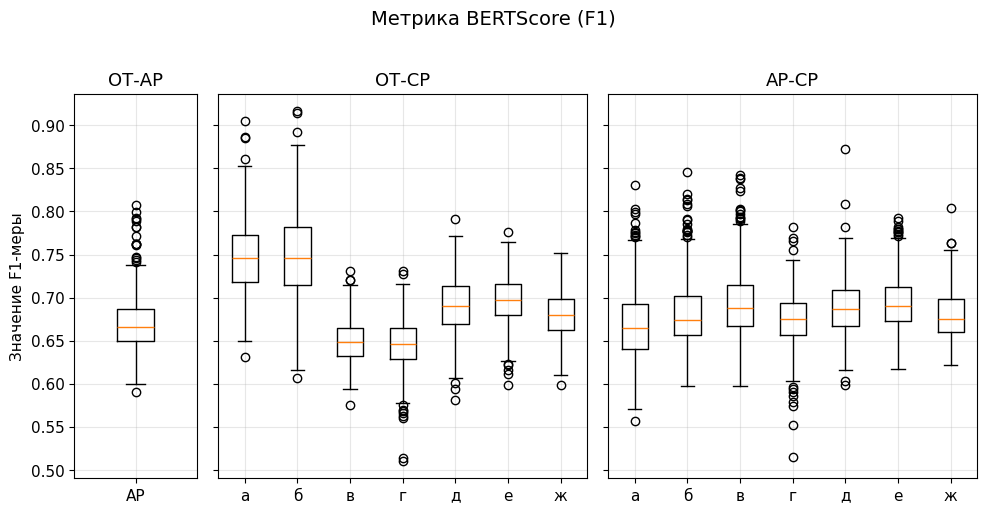

In [20]:
# График BERTScore: 3 подграфика
fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True, tight_layout=True, width_ratios=[1, 3, 3])

# ОТ-АР
axes[0].boxplot([bertscore_results['ОТ-АР']['f1']], labels=['АР'], widths=0.3)
axes[0].set_title('ОТ-АР')
axes[0].set_ylabel('Значение F1-меры')
axes[0].grid(True, alpha=0.3)

# ОТ-СР
data_ot_sr = [bertscore_results['ОТ-СР'][col]['f1'] for col in SR_COLS]
axes[1].boxplot(data_ot_sr, labels=SHORT_LABELS)
axes[1].set_title('ОТ-СР')
axes[1].grid(True, alpha=0.3)

# АР-СР
data_ar_sr = [bertscore_results['АР-СР'][col]['f1'] for col in SR_COLS]
axes[2].boxplot(data_ar_sr, labels=SHORT_LABELS)
axes[2].set_title('АР-СР')
axes[2].grid(True, alpha=0.3)

fig.suptitle('Метрика BERTScore (F1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('bertscore_3comparisons.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
with open('bertscore.json', 'w', encoding='utf-8') as json_file:
    json.dump(bertscore_results, json_file, ensure_ascii=False, indent=4)

## 6. Sentence Embeddings (Косинусное сходство)

In [21]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Загружаем 4 модели эмбеддингов
print('Загрузка моделей эмбеддингов...')
emb_models = {
    'cointegrated/rubert-tiny2': SentenceTransformer('cointegrated/rubert-tiny2', device=device),
    'sergeyzh/LaBSE-ru-sts': SentenceTransformer('sentence-transformers/LaBSE', device=device),
    'uaritm/multilingual_en_ru_uk': SentenceTransformer('uaritm/multilingual_en_ru_uk', device=device),
    'DeepPavlov/rubert-base-cased': SentenceTransformer('DeepPavlov/rubert-base-cased', device=device)
}
print('Модели загружены!')

Загрузка моделей эмбеддингов...


Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Модели загружены!


In [22]:
def compute_cosine_sim(model, texts1, texts2):
    """Вычисляет косинусное сходство между парами текстов"""
    emb1 = model.encode(texts1, show_progress_bar=True, convert_to_numpy=True)
    emb2 = model.encode(texts2, show_progress_bar=True, convert_to_numpy=True)
    return [cosine_similarity([e1], [e2])[0][0] for e1, e2 in zip(emb1, emb2)]

# Структура результатов
embedding_results = {}

for emb_name, emb_model in emb_models.items():
    print(f'\n=== {emb_name} ===')
    embedding_results[emb_name] = {
        'ОТ-АР': [],
        'ОТ-СР': {col: [] for col in SR_COLS},
        'АР-СР': {col: [] for col in SR_COLS}
    }
    
    # ОТ-АР
    print('  ОТ-АР...')
    embedding_results[emb_name]['ОТ-АР'] = compute_cosine_sim(emb_model, ot_texts, ar_texts)
    
    # ОТ-СР и АР-СР
    for col, label in zip(SR_COLS, FULL_LABELS):
        sr_texts = df_clean[col].tolist()
        print(f'  {label}...')
        embedding_results[emb_name]['ОТ-СР'][col] = compute_cosine_sim(emb_model, ot_texts, sr_texts)
        embedding_results[emb_name]['АР-СР'][col] = compute_cosine_sim(emb_model, ar_texts, sr_texts)

print('\nЭмбеддинги вычислены!')


=== cointegrated/rubert-tiny2 ===
  ОТ-АР...


Batches: 100%|██████████| 15/15 [00:00<00:00, 49.08it/s]


  Лингвистический суммаризатор...


Batches: 100%|██████████| 15/15 [00:00<00:00, 17.58it/s]


  TextRank...


...

  IlyaGusev/rut5_base_sum_gazeta...


Batches: 100%|██████████| 15/15 [00:02<00:00,  5.93it/s]


  utrobinmv/t5_summary_en_ru_zh_base_2048...


Batches: 100%|██████████| 15/15 [00:01<00:00,  7.65it/s]



Эмбеддинги вычислены!


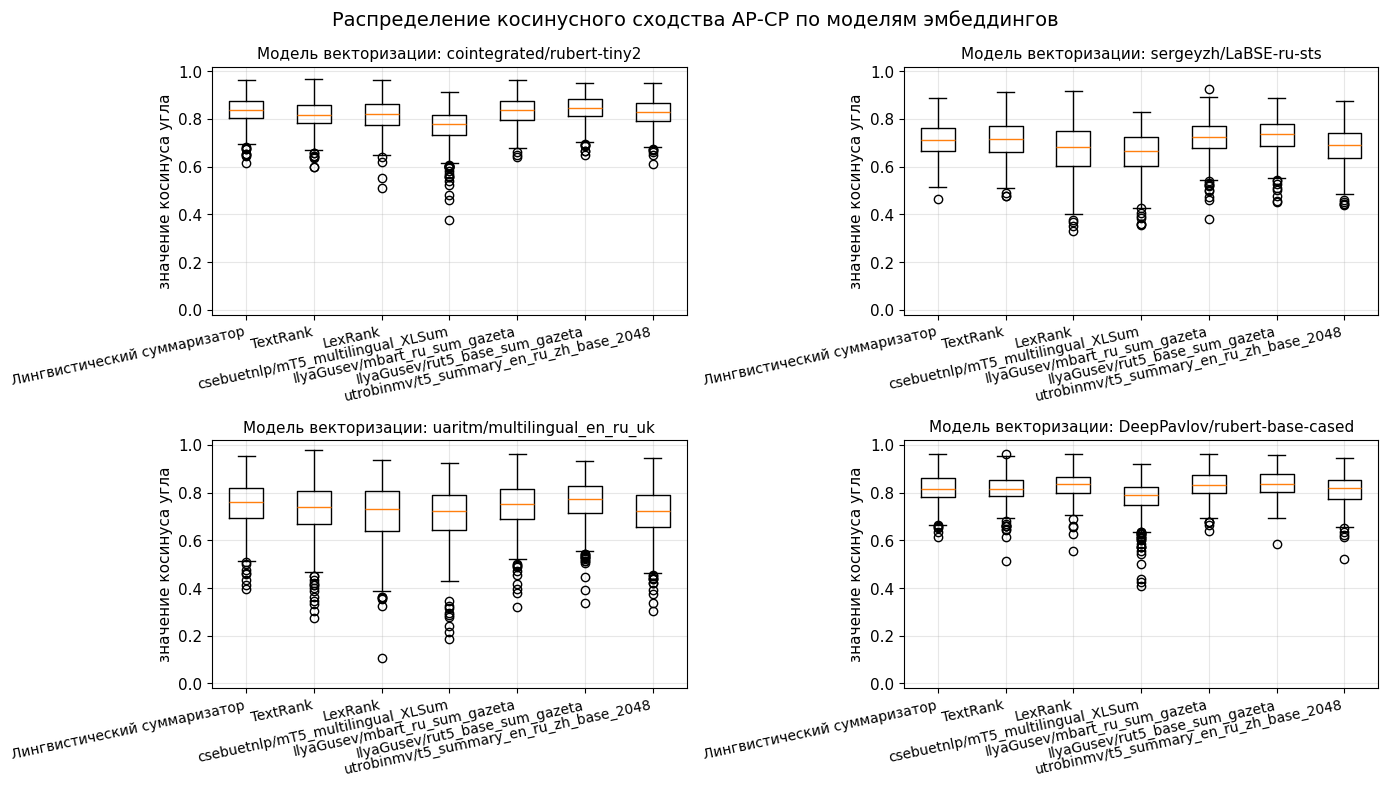

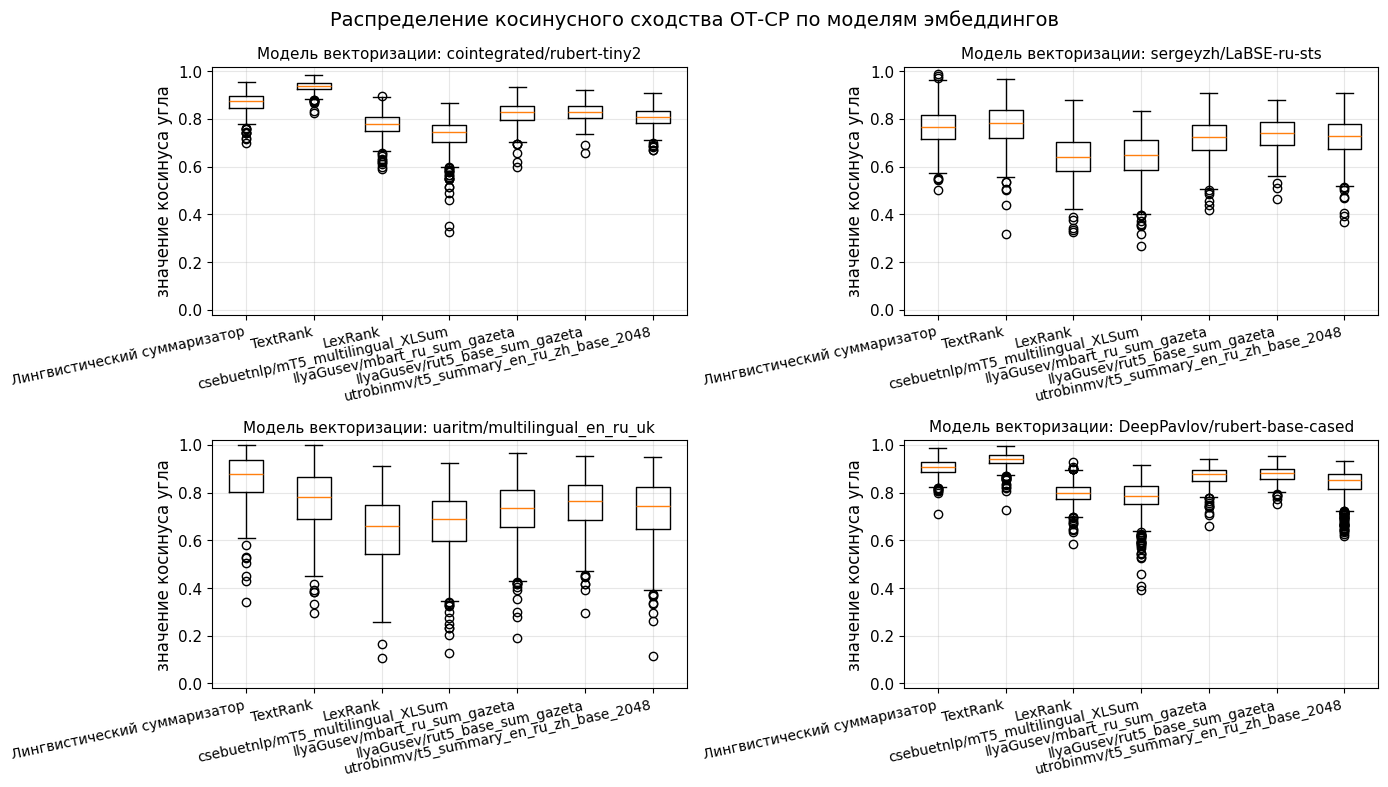

In [23]:
# Графики косинусного сходства: формат 2x2 (АР-СР)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14,8), tight_layout=True)
fig.suptitle('Распределение косинусного сходства АР-СР по моделям эмбеддингов', fontsize=14)

for emb_name, ax in zip(emb_models.keys(), axes.flat):
    # Данные АР-СР для 7 моделей суммаризации
    data = [embedding_results[emb_name]['АР-СР'][col] for col in SR_COLS]
    
    bp = ax.boxplot(data)
    ax.set_xticklabels(FULL_LABELS, rotation=12, ha='right', fontsize=10)
    ax.set_title(f'Модель векторизации: {emb_name}', fontsize=11)
    ax.set_ylabel('значение косинуса угла')
    ax.set_ylim(0.0-0.02, 1.0+0.02)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('embeddings_2x2_ar_sr.png', dpi=150, bbox_inches='tight')
plt.show()

# Дополнительно: сохраним графики ОТ-АР и ОТ-СР в формате 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 8), tight_layout=True)
fig.suptitle('Распределение косинусного сходства ОТ-СР по моделям эмбеддингов', fontsize=14)

for emb_name, ax in zip(emb_models.keys(), axes.flat):
    data = [embedding_results[emb_name]['ОТ-СР'][col] for col in SR_COLS]
    
    bp = ax.boxplot(data)
    ax.set_xticklabels(FULL_LABELS, rotation=12, ha='right', fontsize=10)
    ax.set_title(f'Модель векторизации: {emb_name}', fontsize=11)
    ax.set_ylabel('значение косинуса угла', fontsize=12)
    ax.set_ylim(0.0-0.02, 1.0+0.02)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('embeddings_2x2_ot_sr.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
from typing import Any
def convert_np_floats(obj: Any) -> Any:
    """Рекурсивно преобразует np.float32 в стандартный float"""
    if isinstance(obj, np.float32):
        return float(obj)
    elif isinstance(obj, dict):
        return {key: convert_np_floats(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_np_floats(item) for item in obj]
    elif isinstance(obj, tuple):
        return tuple(convert_np_floats(item) for item in obj)
    else:
        return obj
    
embedding_results_coded = convert_np_floats(embedding_results)

In [39]:
with open('embeddings.json', 'w', encoding='utf-8') as json_file:
    json.dump(embedding_results_coded, json_file, ensure_ascii=False, indent=4)

## 7. BLEURT

In [24]:
from bleurt_pytorch import BleurtConfig, BleurtForSequenceClassification, BleurtTokenizer

print('Загрузка модели BLEURT...')
bleurt_model = BleurtForSequenceClassification.from_pretrained('lucadiliello/BLEURT-20')
bleurt_tokenizer = BleurtTokenizer.from_pretrained('lucadiliello/BLEURT-20')
bleurt_model.to(device)
bleurt_model.eval()
print(f'BLEURT загружен на {device}!')

Загрузка модели BLEURT...


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'BleurtSPTokenizer'. 
The class this function is called from is 'BertTokenizer'.


BLEURT загружен на cuda!


In [25]:
def compute_bleurt(references, candidates, batch_size=8):
    scores = []
    for i in range(0, len(references), batch_size):
        batch_refs = references[i:i+batch_size]
        batch_cands = candidates[i:i+batch_size]
        with torch.no_grad():
            inputs = bleurt_tokenizer(batch_refs, batch_cands, padding='longest',
                                      max_length=512, truncation=True, return_tensors='pt')
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = bleurt_model(**inputs)
            scores.extend(outputs.logits.flatten().tolist())
    return scores

# Структура результатов
bleurt_results = {
    'ОТ-АР': [],
    'ОТ-СР': {col: [] for col in SR_COLS},
    'АР-СР': {col: [] for col in SR_COLS}
}

print('Вычисление BLEURT...')

# ОТ-АР
print('  ОТ-АР...')
bleurt_results['ОТ-АР'] = compute_bleurt(ot_texts, ar_texts)

# ОТ-СР и АР-СР
for col, label in zip(SR_COLS, FULL_LABELS):
    sr_texts = df_clean[col].tolist()
    print(f'  {label}...')
    bleurt_results['ОТ-СР'][col] = compute_bleurt(ot_texts, sr_texts)
    bleurt_results['АР-СР'][col] = compute_bleurt(ar_texts, sr_texts)

print('BLEURT вычислен!')

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

Вычисление BLEURT...
  ОТ-АР...


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

  Лингвистический суммаризатор...


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

...

  IlyaGusev/rut5_base_sum_gazeta...


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

  utrobinmv/t5_summary_en_ru_zh_base_2048...


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

BLEURT вычислен!


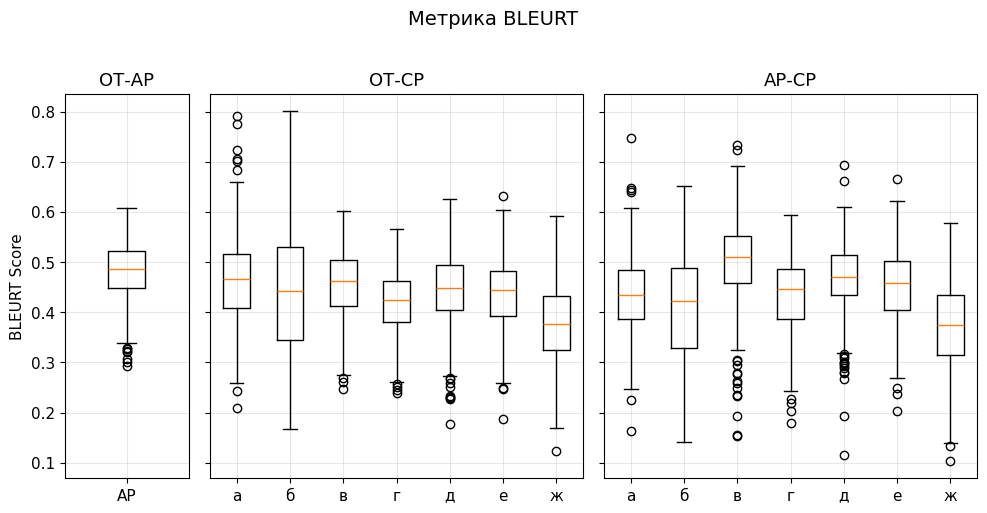

In [26]:
# График BLEURT: 3 подграфика
fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True, tight_layout=True, width_ratios=[1, 3, 3])

# ОТ-АР
axes[0].boxplot([bleurt_results['ОТ-АР']], labels=['АР'], widths=0.3)
axes[0].set_title('ОТ-АР')
axes[0].set_ylabel('BLEURT Score')
axes[0].grid(True, alpha=0.3)

# ОТ-СР
data_ot_sr = [bleurt_results['ОТ-СР'][col] for col in SR_COLS]
axes[1].boxplot(data_ot_sr, labels=SHORT_LABELS)
axes[1].set_title('ОТ-СР')
axes[1].grid(True, alpha=0.3)

# АР-СР
data_ar_sr = [bleurt_results['АР-СР'][col] for col in SR_COLS]
axes[2].boxplot(data_ar_sr, labels=SHORT_LABELS)
axes[2].set_title('АР-СР')
axes[2].grid(True, alpha=0.3)

fig.suptitle('Метрика BLEURT', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('bleurt_3comparisons.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
with open('bleurt.json', 'w', encoding='utf-8') as json_file:
    json.dump(bleurt_results, json_file, ensure_ascii=False, indent=4)

## 8. Сводный анализ

In [27]:
# Создаём три сводные таблицы

# 1. ОТ-АР (одна строка)
summary_ot_ar = pd.DataFrame({
    'ROUGE-1': [np.mean(rouge_results['ОТ-АР']['rouge1']['f'])],
    'ROUGE-2': [np.mean(rouge_results['ОТ-АР']['rouge2']['f'])],
    'ROUGE-L': [np.mean(rouge_results['ОТ-АР']['rougeL']['f'])],
    'BLEU': [np.mean(bleu_results['ОТ-АР'])],
    'chrF++': [np.mean(chrf_results['ОТ-АР'])],
    'METEOR': [np.mean(meteor_results['ОТ-АР'])],
    'BERTScore': [np.mean(bertscore_results['ОТ-АР']['f1'])],
    'Cos (rubert-tiny2)': [np.mean(embedding_results['cointegrated/rubert-tiny2']['ОТ-АР'])],
    'Cos (LaBSE)': [np.mean(embedding_results['sergeyzh/LaBSE-ru-sts']['ОТ-АР'])],
    'Cos (uaritm)': [np.mean(embedding_results['uaritm/multilingual_en_ru_uk']['ОТ-АР'])],
    'Cos (DeepPavlov)': [np.mean(embedding_results['DeepPavlov/rubert-base-cased']['ОТ-АР'])],
    'BLEURT': [np.mean(bleurt_results['ОТ-АР'])]
}, index=['АР'])

print('=== Сводная таблица: ОТ-АР ===')
display(summary_ot_ar.style.format('{:.4f}').background_gradient(cmap='Greens', axis=1))

=== Сводная таблица: ОТ-АР ===


,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,chrF++,METEOR,BERTScore,Cos (rubert-tiny2),Cos (LaBSE),Cos (uaritm),Cos (DeepPavlov),BLEURT
АР,0.0521,0.0323,0.0487,0.0009,0.0495,0.0326,0.6705,0.8001,0.6987,0.7256,0.8213,0.4821


In [28]:
# 2. ОТ-СР
summary_ot_sr = pd.DataFrame(index=FULL_LABELS)
for col, label in zip(SR_COLS, FULL_LABELS):
    summary_ot_sr.loc[label, 'ROUGE-1'] = np.mean(rouge_results['ОТ-СР'][col]['rouge1']['f'])
    summary_ot_sr.loc[label, 'ROUGE-2'] = np.mean(rouge_results['ОТ-СР'][col]['rouge2']['f'])
    summary_ot_sr.loc[label, 'ROUGE-L'] = np.mean(rouge_results['ОТ-СР'][col]['rougeL']['f'])
    summary_ot_sr.loc[label, 'BLEU'] = np.mean(bleu_results['ОТ-СР'][col])
    summary_ot_sr.loc[label, 'chrF++'] = np.mean(chrf_results['ОТ-СР'][col])
    summary_ot_sr.loc[label, 'METEOR'] = np.mean(meteor_results['ОТ-СР'][col])
    summary_ot_sr.loc[label, 'BERTScore'] = np.mean(bertscore_results['ОТ-СР'][col]['f1'])
    summary_ot_sr.loc[label, 'Cos (rubert-tiny2)'] = np.mean(embedding_results['cointegrated/rubert-tiny2']['ОТ-СР'][col])
    summary_ot_sr.loc[label, 'Cos (LaBSE)'] = np.mean(embedding_results['sergeyzh/LaBSE-ru-sts']['ОТ-СР'][col])
    summary_ot_sr.loc[label, 'Cos (uaritm)'] = np.mean(embedding_results['uaritm/multilingual_en_ru_uk']['ОТ-СР'][col])
    summary_ot_sr.loc[label, 'Cos (DeepPavlov)'] = np.mean(embedding_results['DeepPavlov/rubert-base-cased']['ОТ-СР'][col])
    summary_ot_sr.loc[label, 'BLEURT'] = np.mean(bleurt_results['ОТ-СР'][col])

print('=== Сводная таблица: ОТ-СР ===')
display(summary_ot_sr.style.format('{:.4f}').background_gradient(cmap='Blues', axis=0))

=== Сводная таблица: ОТ-СР ===


,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,chrF++,METEOR,BERTScore,Cos (rubert-tiny2),Cos (LaBSE),Cos (uaritm),Cos (DeepPavlov),BLEURT
Лингвистический суммаризатор,0.2260,0.1751,0.1995,0.0065,0.1474,0.1048,0.7468,0.8697,0.7644,0.8592,0.9052,0.4644
TextRank,0.3798,0.2781,0.3798,0.1224,0.3628,0.2524,0.7490,0.9362,0.7721,0.7657,0.9379,0.4413
LexRank,0.0329,0.0205,0.0310,0.0001,0.0440,0.0250,0.6493,0.7754,0.6379,0.6390,0.7981,0.4562
csebuetnlp/mT5_multilingual_XLSum,0.0268,0.0075,0.0262,0.0000,0.0338,0.0210,0.6454,0.7337,0.6426,0.6709,0.7747,0.4196
IlyaGusev/mbart_ru_sum_gazeta,0.0775,0.0434,0.0746,0.0000,0.0780,0.0531,0.6905,0.8234,0.7168,0.7245,0.8702,0.4450
IlyaGusev/rut5_base_sum_gazeta,0.0688,0.0369,0.0673,0.0000,0.0806,0.0553,0.6966,0.8290,0.7359,0.7505,0.8759,0.4379
utrobinmv/t5_summary_en_ru_zh_base_2048,0.0766,0.0409,0.0752,0.0000,0.0567,0.0395,0.6796,0.8073,0.7178,0.7257,0.8361,0.3771


In [29]:
# 3. АР-СР
summary_ar_sr = pd.DataFrame(index=FULL_LABELS)
for col, label in zip(SR_COLS, FULL_LABELS):
    summary_ar_sr.loc[label, 'ROUGE-1'] = np.mean(rouge_results['АР-СР'][col]['rouge1']['f'])
    summary_ar_sr.loc[label, 'ROUGE-2'] = np.mean(rouge_results['АР-СР'][col]['rouge2']['f'])
    summary_ar_sr.loc[label, 'ROUGE-L'] = np.mean(rouge_results['АР-СР'][col]['rougeL']['f'])
    summary_ar_sr.loc[label, 'BLEU'] = np.mean(bleu_results['АР-СР'][col])
    summary_ar_sr.loc[label, 'chrF++'] = np.mean(chrf_results['АР-СР'][col])
    summary_ar_sr.loc[label, 'METEOR'] = np.mean(meteor_results['АР-СР'][col])
    summary_ar_sr.loc[label, 'BERTScore'] = np.mean(bertscore_results['АР-СР'][col]['f1'])
    summary_ar_sr.loc[label, 'Cos (rubert-tiny2)'] = np.mean(embedding_results['cointegrated/rubert-tiny2']['АР-СР'][col])
    summary_ar_sr.loc[label, 'Cos (LaBSE)'] = np.mean(embedding_results['sergeyzh/LaBSE-ru-sts']['АР-СР'][col])
    summary_ar_sr.loc[label, 'Cos (uaritm)'] = np.mean(embedding_results['uaritm/multilingual_en_ru_uk']['АР-СР'][col])
    summary_ar_sr.loc[label, 'Cos (DeepPavlov)'] = np.mean(embedding_results['DeepPavlov/rubert-base-cased']['АР-СР'][col])
    summary_ar_sr.loc[label, 'BLEURT'] = np.mean(bleurt_results['АР-СР'][col])

print('=== Сводная таблица: АР-СР ===')
display(summary_ar_sr.style.format('{:.4f}').background_gradient(cmap='Oranges', axis=0))

=== Сводная таблица: АР-СР ===


,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,chrF++,METEOR,BERTScore,Cos (rubert-tiny2),Cos (LaBSE),Cos (uaritm),Cos (DeepPavlov),BLEURT
Лингвистический суммаризатор,0.1247,0.0545,0.1111,0.0312,0.3427,0.2864,0.6691,0.8358,0.7127,0.7505,0.8208,0.4335
TextRank,0.1025,0.0520,0.0894,0.0272,0.2664,0.2510,0.6830,0.8185,0.7152,0.7259,0.8186,0.4061
LexRank,0.1151,0.0708,0.1049,0.0386,0.3063,0.2028,0.6931,0.8160,0.6759,0.7155,0.8314,0.5011
csebuetnlp/mT5_multilingual_XLSum,0.0779,0.0254,0.0758,0.0163,0.2827,0.1786,0.6739,0.7672,0.6547,0.7075,0.7758,0.4358
IlyaGusev/mbart_ru_sum_gazeta,0.1439,0.0599,0.1366,0.0264,0.3419,0.2520,0.6890,0.8337,0.7188,0.7465,0.8339,0.4694
IlyaGusev/rut5_base_sum_gazeta,0.1326,0.0567,0.1252,0.0293,0.3500,0.2680,0.6934,0.8455,0.7303,0.7630,0.8398,0.4511
utrobinmv/t5_summary_en_ru_zh_base_2048,0.1100,0.0401,0.1043,0.0204,0.3153,0.2062,0.6791,0.8229,0.6833,0.7140,0.8106,0.3703


In [30]:
print('=== Сводная таблица: ОТ-АР ===')
display(summary_ot_ar.style.format('{:.4f}').background_gradient(cmap='Greens', axis=1))
print('=== Сводная таблица: ОТ-СР ===')
display(summary_ot_sr.style.format('{:.4f}').background_gradient(cmap='Blues', axis=0))
print('=== Сводная таблица: АР-СР ===')
display(summary_ar_sr.style.format('{:.4f}').background_gradient(cmap='Oranges', axis=0))

=== Сводная таблица: ОТ-АР ===


,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,chrF++,METEOR,BERTScore,Cos (rubert-tiny2),Cos (LaBSE),Cos (uaritm),Cos (DeepPavlov),BLEURT
АР,0.0521,0.0323,0.0487,0.0009,0.0495,0.0326,0.6705,0.8001,0.6987,0.7256,0.8213,0.4821


=== Сводная таблица: ОТ-СР ===


,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,chrF++,METEOR,BERTScore,Cos (rubert-tiny2),Cos (LaBSE),Cos (uaritm),Cos (DeepPavlov),BLEURT
Лингвистический суммаризатор,0.2260,0.1751,0.1995,0.0065,0.1474,0.1048,0.7468,0.8697,0.7644,0.8592,0.9052,0.4644
TextRank,0.3798,0.2781,0.3798,0.1224,0.3628,0.2524,0.7490,0.9362,0.7721,0.7657,0.9379,0.4413
LexRank,0.0329,0.0205,0.0310,0.0001,0.0440,0.0250,0.6493,0.7754,0.6379,0.6390,0.7981,0.4562
csebuetnlp/mT5_multilingual_XLSum,0.0268,0.0075,0.0262,0.0000,0.0338,0.0210,0.6454,0.7337,0.6426,0.6709,0.7747,0.4196
IlyaGusev/mbart_ru_sum_gazeta,0.0775,0.0434,0.0746,0.0000,0.0780,0.0531,0.6905,0.8234,0.7168,0.7245,0.8702,0.4450
IlyaGusev/rut5_base_sum_gazeta,0.0688,0.0369,0.0673,0.0000,0.0806,0.0553,0.6966,0.8290,0.7359,0.7505,0.8759,0.4379
utrobinmv/t5_summary_en_ru_zh_base_2048,0.0766,0.0409,0.0752,0.0000,0.0567,0.0395,0.6796,0.8073,0.7178,0.7257,0.8361,0.3771


=== Сводная таблица: АР-СР ===


,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,chrF++,METEOR,BERTScore,Cos (rubert-tiny2),Cos (LaBSE),Cos (uaritm),Cos (DeepPavlov),BLEURT
Лингвистический суммаризатор,0.1247,0.0545,0.1111,0.0312,0.3427,0.2864,0.6691,0.8358,0.7127,0.7505,0.8208,0.4335
TextRank,0.1025,0.0520,0.0894,0.0272,0.2664,0.2510,0.6830,0.8185,0.7152,0.7259,0.8186,0.4061
LexRank,0.1151,0.0708,0.1049,0.0386,0.3063,0.2028,0.6931,0.8160,0.6759,0.7155,0.8314,0.5011
csebuetnlp/mT5_multilingual_XLSum,0.0779,0.0254,0.0758,0.0163,0.2827,0.1786,0.6739,0.7672,0.6547,0.7075,0.7758,0.4358
IlyaGusev/mbart_ru_sum_gazeta,0.1439,0.0599,0.1366,0.0264,0.3419,0.2520,0.6890,0.8337,0.7188,0.7465,0.8339,0.4694
IlyaGusev/rut5_base_sum_gazeta,0.1326,0.0567,0.1252,0.0293,0.3500,0.2680,0.6934,0.8455,0.7303,0.7630,0.8398,0.4511
utrobinmv/t5_summary_en_ru_zh_base_2048,0.1100,0.0401,0.1043,0.0204,0.3153,0.2062,0.6791,0.8229,0.6833,0.7140,0.8106,0.3703


In [31]:
# Финальные выводы
print('=' * 70)
print('ИТОГОВЫЕ ВЫВОДЫ')
print('=' * 70)

print('\n--- Лучшие модели по АР-ОТ ---')
for metric in summary_ot_ar.columns:
    best_model = summary_ot_ar[metric].idxmax()
    best_value = summary_ot_ar[metric].max()
    print(f'{metric:15s}: {best_model:10s} ({best_value:.4f})')

print('\n' + '=' * 70)

print('\n--- Лучшие модели по ОТ-СР (сравнение с оригинальным текстом) ---')
for metric in summary_ot_sr.columns:
    best_model = summary_ot_sr[metric].idxmax()
    best_value = summary_ot_sr[metric].max()
    print(f'{metric:15s}: {best_model:10s} ({best_value:.4f})')

print('\n' + '=' * 70)

print('\n--- Лучшие модели по АР-СР (сравнение с авторским рефератом) ---')
for metric in summary_ar_sr.columns:
    best_model = summary_ar_sr[metric].idxmax()
    best_value = summary_ar_sr[metric].max()
    print(f'{metric:15s}: {best_model:10s} ({best_value:.4f})')

print('\n' + '=' * 70)

ИТОГОВЫЕ ВЫВОДЫ

--- Лучшие модели по АР-ОТ ---
ROUGE-1        : АР         (0.0521)
ROUGE-2        : АР         (0.0323)
ROUGE-L        : АР         (0.0487)
BLEU           : АР         (0.0009)
chrF++         : АР         (0.0495)
METEOR         : АР         (0.0326)
BERTScore      : АР         (0.6705)
Cos (rubert-tiny2): АР         (0.8001)
Cos (LaBSE)    : АР         (0.6987)
Cos (uaritm)   : АР         (0.7256)
Cos (DeepPavlov): АР         (0.8213)
BLEURT         : АР         (0.4821)


--- Лучшие модели по ОТ-СР (сравнение с оригинальным текстом) ---
ROUGE-1        : TextRank   (0.3798)
ROUGE-2        : TextRank   (0.2781)
ROUGE-L        : TextRank   (0.3798)
BLEU           : TextRank   (0.1224)
chrF++         : TextRank   (0.3628)
METEOR         : TextRank   (0.2524)
BERTScore      : TextRank   (0.7490)
Cos (rubert-tiny2): TextRank   (0.9362)
Cos (LaBSE)    : TextRank   (0.7721)
Cos (uaritm)   : Лингвистический суммаризатор (0.8592)
Cos (DeepPavlov): TextRank   (0.9379)
BLEURT 

In [33]:
# Сохранение результатов
with pd.ExcelWriter('summarization_results_3comparisons.xlsx') as writer:
    summary_ot_ar.to_excel(writer, sheet_name='ОТ-АР')
    summary_ot_sr.to_excel(writer, sheet_name='ОТ-СР')
    summary_ar_sr.to_excel(writer, sheet_name='АР-СР')

print('Результаты сохранены в summarization_results_3comparisons.xlsx')

Результаты сохранены в summarization_results_3comparisons.xlsx
